Shape: (1309, 14)
   pclass                                             name     sex      age  \
0       1                    Allen, Miss. Elisabeth Walton  female  29.0000   
1       1                   Allison, Master. Hudson Trevor    male   0.9167   
2       1                     Allison, Miss. Helen Loraine  female   2.0000   
3       1             Allison, Mr. Hudson Joshua Creighton    male  30.0000   
4       1  Allison, Mrs. Hudson J C (Bessie Waldo Daniels)  female  25.0000   

   sibsp  parch  ticket      fare    cabin embarked boat   body  \
0      0      0   24160  211.3375       B5        S    2    NaN   
1      1      2  113781  151.5500  C22 C26        S   11    NaN   
2      1      2  113781  151.5500  C22 C26        S  NaN    NaN   
3      1      2  113781  151.5500  C22 C26        S  NaN  135.0   
4      1      2  113781  151.5500  C22 C26        S  NaN    NaN   

                         home.dest  survived  
0                     St Louis, MO         1  
1  Montrea

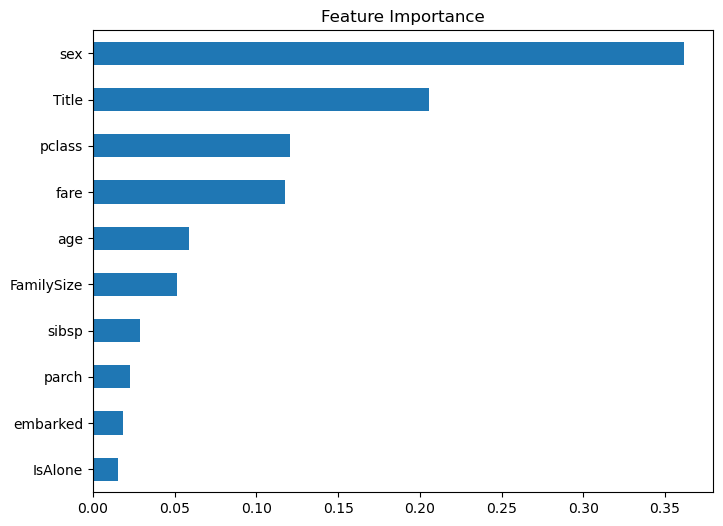

In [30]:
# =====================================
# 1. 라이브러리
# =====================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import KFold

# =====================================
# 2. 데이터 로드
# =====================================
# df = pd.read_csv("titanic_X.csv")
X = pd.read_csv('titanic_X.csv')
y = pd.read_csv('titanic_y.csv')
df = pd.concat([X, y], axis=1)

print("Shape:", df.shape)
print(df.head())

# =====================================
# 3. 기본 EDA
# =====================================
print("\n===== INFO =====")
print(df.info())

print("\n===== DESCRIBE =====")
print(df.describe())

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

# =====================================
# 4. 결측치 처리
# =====================================

# Age → 평균값
df["age"] = df["age"].fillna(df["age"].mean())

# Embarked → 최빈값
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])

# Cabin → 너무 많아서 제거
df.drop("cabin", axis=1, inplace=True)

# =====================================
# 5. Feature Engineering
# =====================================

# 이름에서 호칭 추출
df["Title"] = df["name"].str.extract("([A-Za-z]+)\.")

# 가족 수
df["FamilySize"] = df["sibsp"] + df["parch"] + 1

# 혼자인지 여부
df["IsAlone"] = 1
df.loc[df["FamilySize"] > 1, "IsAlone"] = 0

# 필요 없는 컬럼 제거
df.drop(["name","ticket", 'boat', 'body', 'home.dest'], axis=1, inplace=True)

# =====================================
# 6. 범주형 인코딩
# =====================================
le = LabelEncoder()

cat_cols = ["sex","embarked","Title"]

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

# =====================================
# 7. Train / Test Split
# =====================================
X = df.drop("survived", axis=1)
y = df["survived"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =====================================
# 8. 모델 학습
# =====================================
model = RandomForestClassifier(
    n_estimators=150,
    max_depth=5,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

# =====================================
# 9. 예측
# =====================================
pred = model.predict(X_test)

# =====================================
# 10. 모델 평가
# =====================================
print("\n===== Accuracy =====")
print(accuracy_score(y_test, pred))

print("\n===== Classification Report =====")
print(classification_report(y_test, pred))

# 3. 교차 검증 다시 실행
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=kf) # kf를 직접 전달!

print(f"5-Fold CV 평균 (셔플 포함): {cv_scores.mean():.4f}")
print(f"각 폴드별 점수: {cv_scores}")

# =====================================
# 11. Feature Importance
# =====================================
importance = pd.Series(model.feature_importances_, index=X.columns)

importance.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Feature Importance")
plt.show()

In [31]:
df

,pclass,sex,age,sibsp,parch,fare,embarked,survived,Title,FamilySize,IsAlone
0,1,0,29.000000,0,0,211.3375,2,1,10,1,1
1,1,1,0.916700,1,2,151.5500,2,1,9,4,0
2,1,0,2.000000,1,2,151.5500,2,0,10,4,0
3,1,1,30.000000,1,2,151.5500,2,0,13,4,0
4,1,0,25.000000,1,2,151.5500,2,0,14,4,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,0,14.500000,1,0,14.4542,0,0,10,2,0
1305,3,0,29.881135,1,0,14.4542,0,0,10,2,0
1306,3,1,26.500000,0,0,7.2250,0,0,13,1,1
1307,3,1,27.000000,0,0,7.2250,0,0,13,1,1
